# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 [==============================] - 3918s 23us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

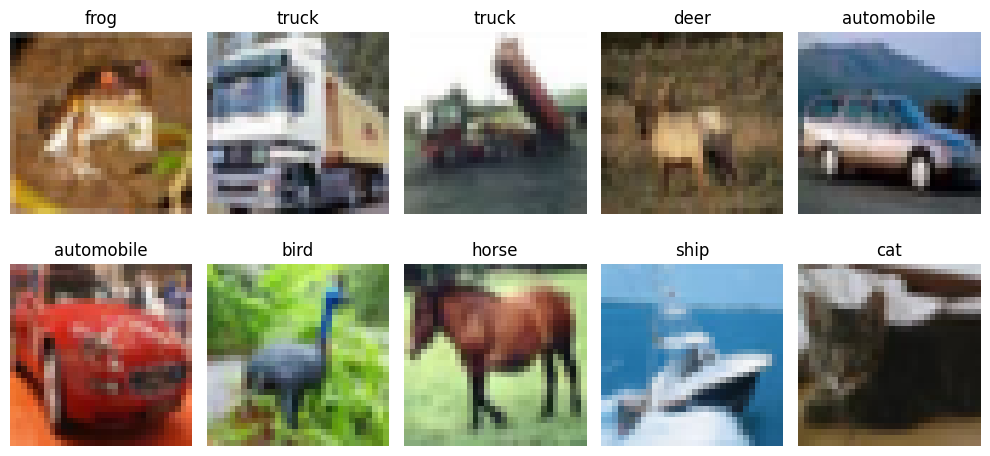

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)



Epoch 1/10


704/704 [==============================] - 7s 9ms/step - loss: 2.0149 - accuracy: 0.2607 - val_loss: 1.8715 - val_accuracy: 0.3238
Epoch 2/10
704/704 [==============================] - 6s 8ms/step - loss: 1.8777 - accuracy: 0.3170 - val_loss: 1.7678 - val_accuracy: 0.3698
Epoch 3/10
704/704 [==============================] - 6s 9ms/step - loss: 1.8214 - accuracy: 0.3350 - val_loss: 1.7571 - val_accuracy: 0.3664
Epoch 4/10
704/704 [==============================] - 6s 8ms/step - loss: 1.7831 - accuracy: 0.3512 - val_loss: 1.7337 - val_accuracy: 0.3804
Epoch 5/10
704/704 [==============================] - 6s 9ms/step - loss: 1.7733 - accuracy: 0.3525 - val_loss: 1.6936 - val_accuracy: 0.4068
Epoch 6/10
704/704 [==============================] - 6s 8ms/step - loss: 1.7463 - accuracy: 0.3635 - val_loss: 1.6859 - val_accuracy: 0.4066
Epoch 7/10
704/704 [==============================] - 6s 8ms/step - loss: 1.7281 - accuracy: 0.3704 - val_loss: 1.7036 - val_accuracy: 0.3984
Ep

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 1.6499 - accuracy: 0.4159
ANN Test Accuracy: 0.41589999198913574


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 [==============================] - 12s 15ms/step - loss: 1.4775 - accuracy: 0.4716 - val_loss: 1.1135 - val_accuracy: 0.6098
Epoch 2/10
704/704 [==============================] - 10s 14ms/step - loss: 1.1161 - accuracy: 0.6127 - val_loss: 1.2098 - val_accuracy: 0.5760
Epoch 3/10
704/704 [==============================] - 10s 14ms/step - loss: 0.9631 - accuracy: 0.6677 - val_loss: 1.7108 - val_accuracy: 0.4020
Epoch 4/10
704/704 [==============================] - 10s 15ms/step - loss: 0.8529 - accuracy: 0.7034 - val_loss: 1.7577 - val_accuracy: 0.5190
Epoch 5/10
704/704 [==============================] - 10s 15ms/step - loss: 0.7585 - accuracy: 0.7360 - val_loss: 0.9283 - val_accuracy: 0.6850
Epoch 6/10
704/704 [==============================] - 10s 15ms/step - loss: 0.6823 - accuracy: 0.7595 - val_loss: 0.8357 - val_accuracy: 0.7160
Epoch 7/10
704/704 [==============================] - 11s 16ms/step - loss: 0.6164 - accuracy: 0.7832 - val_loss: 1.0573 - val_accuracy

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 [==============================] - 1s 5ms/step - loss: 0.9748 - accuracy: 0.7008
CNN Test Accuracy: 0.7008000016212463


## 📈 Compare Learning Curves

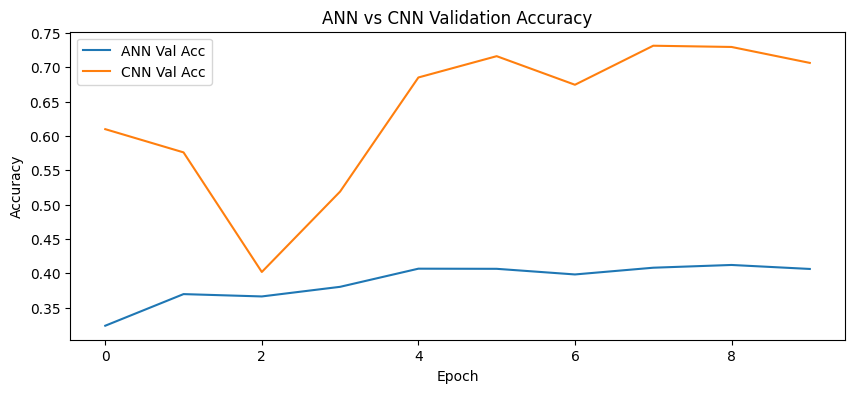

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 🔹 Part 3: Enhanced ANN — More Layers + EarlyStopping
Deeper architecture (1024→512→256→128) with EarlyStopping and 20 max epochs.

In [11]:
enhanced_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

enhanced_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ann = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

enhanced_ann_history = enhanced_ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_ann]
)

Epoch 1/20
704/704 [==============================] - 13s 17ms/step - loss: 2.0777 - accuracy: 0.2278 - val_loss: 1.9031 - val_accuracy: 0.2984
Epoch 2/20
704/704 [==============================] - 11s 16ms/step - loss: 1.9254 - accuracy: 0.2856 - val_loss: 1.8203 - val_accuracy: 0.3292
Epoch 3/20
704/704 [==============================] - 11s 16ms/step - loss: 1.8861 - accuracy: 0.3016 - val_loss: 1.8708 - val_accuracy: 0.3364
Epoch 4/20
704/704 [==============================] - 13s 18ms/step - loss: 1.8557 - accuracy: 0.3165 - val_loss: 1.8496 - val_accuracy: 0.3336
Epoch 5/20
704/704 [==============================] - 13s 18ms/step - loss: 1.8388 - accuracy: 0.3203 - val_loss: 1.8100 - val_accuracy: 0.3432
Epoch 6/20
704/704 [==============================] - 13s 18ms/step - loss: 1.8200 - accuracy: 0.3326 - val_loss: 1.7990 - val_accuracy: 0.3658
Epoch 7/20
704/704 [==============================] - 12s 17ms/step - loss: 1.8019 - accuracy: 0.3411 - val_loss: 1.7980 - val_accuracy:

In [12]:
enhanced_ann_loss, enhanced_ann_acc = enhanced_ann_model.evaluate(x_test_flat, y_test)
print("Enhanced ANN Test Accuracy:", enhanced_ann_acc)

313/313 [==============================] - 1s 3ms/step - loss: 1.6600 - accuracy: 0.4034
Enhanced ANN Test Accuracy: 0.4034000039100647


# 🔹 Part 4: Enhanced CNN — EarlyStopping + 20 Epochs
Same CNN architecture trained longer with EarlyStopping for better convergence.

In [13]:
enhanced_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

enhanced_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

enhanced_cnn_history = enhanced_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn]
)

Epoch 1/20
704/704 [==============================] - 13s 18ms/step - loss: 1.5005 - accuracy: 0.4617 - val_loss: 1.2853 - val_accuracy: 0.5432
Epoch 2/20
704/704 [==============================] - 12s 17ms/step - loss: 1.1296 - accuracy: 0.6049 - val_loss: 1.2840 - val_accuracy: 0.5490
Epoch 3/20
704/704 [==============================] - 11s 16ms/step - loss: 0.9514 - accuracy: 0.6676 - val_loss: 1.0522 - val_accuracy: 0.6322
Epoch 4/20
704/704 [==============================] - 11s 16ms/step - loss: 0.8329 - accuracy: 0.7068 - val_loss: 1.4159 - val_accuracy: 0.5560
Epoch 5/20
704/704 [==============================] - 14s 20ms/step - loss: 0.7396 - accuracy: 0.7431 - val_loss: 0.9236 - val_accuracy: 0.6922
Epoch 6/20
704/704 [==============================] - 12s 17ms/step - loss: 0.6546 - accuracy: 0.7693 - val_loss: 1.0854 - val_accuracy: 0.6586
Epoch 7/20
704/704 [==============================] - 11s 15ms/step - loss: 0.5876 - accuracy: 0.7920 - val_loss: 0.8533 - val_accuracy:

In [14]:
enhanced_cnn_loss, enhanced_cnn_acc = enhanced_cnn_model.evaluate(x_test_norm, y_test)
print("Enhanced CNN Test Accuracy:", enhanced_cnn_acc)

313/313 [==============================] - 1s 4ms/step - loss: 0.8983 - accuracy: 0.7078
Enhanced CNN Test Accuracy: 0.7077999711036682


# 🔹 Part 5: CNN with Data Augmentation + EarlyStopping
Data augmentation helps the model generalize by seeing varied versions of training images.

In [15]:
early_stop_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)

Epoch 1/20
704/704 [==============================] - 12s 14ms/step - loss: 1.7580 - accuracy: 0.3610 - val_loss: 1.4168 - val_accuracy: 0.4878
Epoch 2/20
704/704 [==============================] - 9s 12ms/step - loss: 1.5117 - accuracy: 0.4535 - val_loss: 1.3201 - val_accuracy: 0.5314
Epoch 3/20
704/704 [==============================] - 8s 12ms/step - loss: 1.4049 - accuracy: 0.4964 - val_loss: 1.2293 - val_accuracy: 0.5616
Epoch 4/20
704/704 [==============================] - 8s 12ms/step - loss: 1.3378 - accuracy: 0.5233 - val_loss: 1.0889 - val_accuracy: 0.6130
Epoch 5/20
704/704 [==============================] - 9s 12ms/step - loss: 1.2919 - accuracy: 0.5419 - val_loss: 1.0800 - val_accuracy: 0.6190
Epoch 6/20
704/704 [==============================] - 9s 12ms/step - loss: 1.2607 - accuracy: 0.5566 - val_loss: 1.0715 - val_accuracy: 0.6172
Epoch 7/20
704/704 [==============================] - 9s 13ms/step - loss: 1.2387 - accuracy: 0.5639 - val_loss: 1.0941 - val_accuracy: 0.612

In [16]:
aug_cnn_loss, aug_cnn_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_acc)

313/313 [==============================] - 1s 4ms/step - loss: 0.9555 - accuracy: 0.6628
Augmented CNN Test Accuracy: 0.6628000140190125


# 📊 Final Comparison — All Models

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "Enhanced ANN", "CNN", "Enhanced CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, enhanced_ann_acc, cnn_test_acc, enhanced_cnn_acc, aug_cnn_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4159
1,Enhanced ANN,0.4034
2,CNN,0.7008
3,Enhanced CNN,0.7078
4,Augmented CNN,0.6628


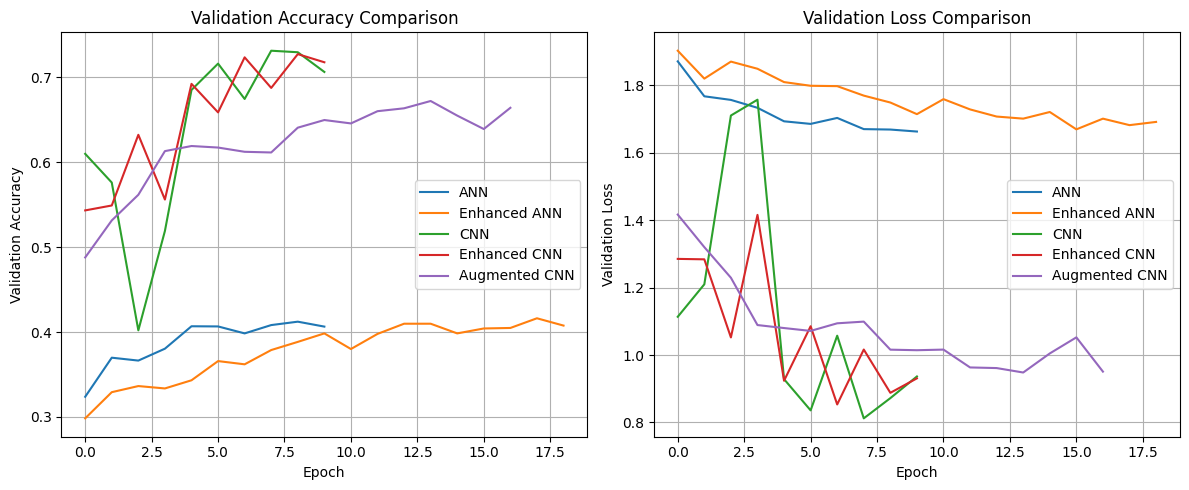

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ann_history.history['val_accuracy'], label='ANN', lw=1.5)
plt.plot(enhanced_ann_history.history['val_accuracy'], label='Enhanced ANN', lw=1.5)
plt.plot(cnn_history.history['val_accuracy'], label='CNN', lw=1.5)
plt.plot(enhanced_cnn_history.history['val_accuracy'], label='Enhanced CNN', lw=1.5)
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN', lw=1.5)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(ann_history.history['val_loss'], label='ANN', lw=1.5)
plt.plot(enhanced_ann_history.history['val_loss'], label='Enhanced ANN', lw=1.5)
plt.plot(cnn_history.history['val_loss'], label='CNN', lw=1.5)
plt.plot(enhanced_cnn_history.history['val_loss'], label='Enhanced CNN', lw=1.5)
plt.plot(aug_history.history['val_loss'], label='Augmented CNN', lw=1.5)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**